In [1]:
#%pip install librosa

In [2]:
#get specific audio file and check its length
import librosa

file = "train_soundscapes/BC2026_Train_0001_S08_20250606_030007.ogg"

y, sr = librosa.load(file, sr=None)

print("Audio length:", len(y)/sr, "seconds")

c:\Users\bulle\anaconda3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Audio length: 60.0 seconds


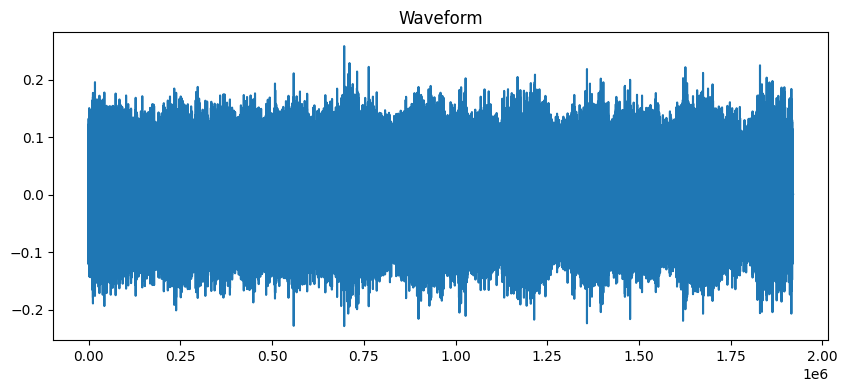

In [3]:
#visualize the waveform
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y)
plt.title("Waveform")
plt.show()

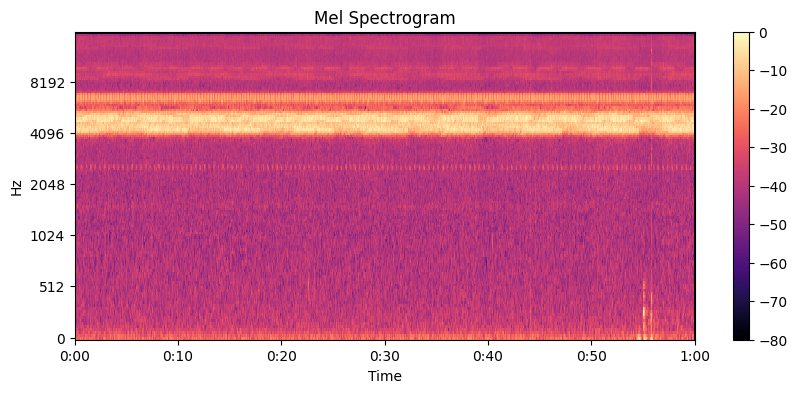

In [4]:
#visualize the spectrogram
import numpy as np
import librosa.display

S = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    S_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

In [5]:
#initial thoughts

#lower frequency don't get affected by the terrain as much as higher frequencies, so if ml model learns primarily lower frequencies, 
# this might lead to worse classification for higher frequency animals if applied. 
# Higher frequencies are more likely to be affected by the terrain




#we need to explore the variation in frequency for each location and see the variance in species frequencies compared to normal recordings of the species
#more than likely the species audio recording are taken in ideal conditions compared to this   




In [6]:
import pandas as pd
import numpy as np
train = pd.read_csv("train.csv")

In [7]:
#explore labels
train.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [8]:
#how to connect the audio files to the labels?

#we have audio of the species in the train_audio and we have audio from recorders 

#each recorder will have that background noise hopefully constant, so that is an assumption

In [9]:
#%pip install geopandas

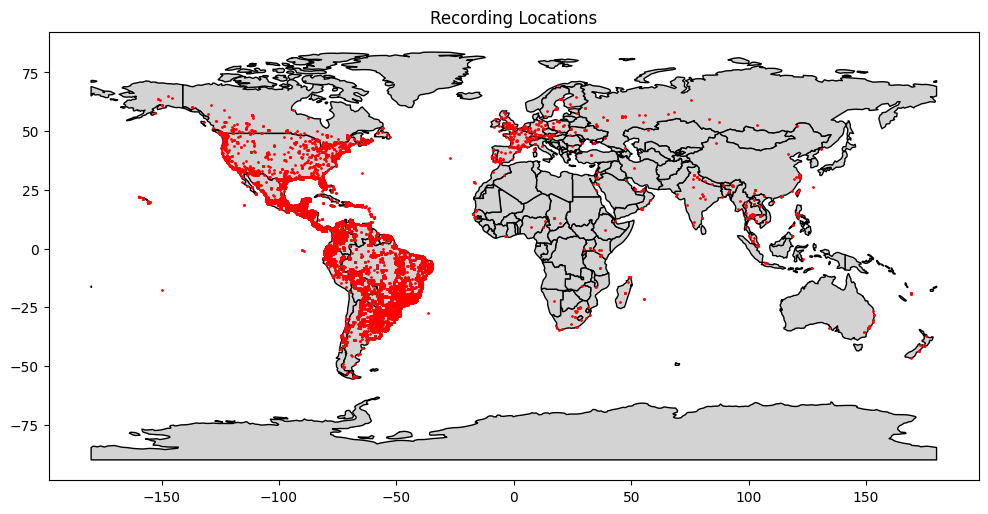

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

world = gpd.read_file("maps/ne_110m_admin_0_countries.shp")

gdf = gpd.GeoDataFrame(
    train,
    geometry=gpd.points_from_xy(train.longitude, train.latitude)
)

ax = world.plot(figsize=(12,6), color="lightgray", edgecolor="black")
gdf.plot(ax=ax, markersize=1, color="red")

plt.title("Recording Locations")
plt.show()

In [11]:
#train_audio is recording of the species



In [12]:
#what is train_soundscapes?
train_soundscapes = pd.read_csv("train_soundscapes_labels.csv")
train_soundscapes.head()

#in primary_label the semicolon separates the species in the recording, so we can split on that to get the individual species
train_soundscapes["species_list"] = train_soundscapes["primary_label"].str.split(";")
train_soundscapes.head()

#now we have to link the soundscapes to the recording of each individual species of animal


,filename,start,end,primary_label,species_list
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"


In [13]:
#linking species to recordings
import os
import pandas as pd

audio_dir = "train_audio"

rows = []

for species in os.listdir(audio_dir):

    species_path = os.path.join(audio_dir, species)

    if os.path.isdir(species_path):

        for file in os.listdir(species_path):

            if file.endswith(".ogg"):
                
                rows.append({
                    "species": species,
                    "file": file,
                    "path": os.path.join(species_path, file)
                })

audio_df = pd.DataFrame(rows)

audio_df.head()

,species,file,path
0,1161364,iNat1114648.ogg,train_audio\1161364\iNat1114648.ogg
1,1161364,iNat1216197.ogg,train_audio\1161364\iNat1216197.ogg
2,1161364,iNat1264238.ogg,train_audio\1161364\iNat1264238.ogg
3,1161364,iNat547199.ogg,train_audio\1161364\iNat547199.ogg
4,1161364,iNat556514.ogg,train_audio\1161364\iNat556514.ogg


In [14]:
#check how many recordings we have for each species
audio_df["species"].value_counts()

species
rubthr1    499
banana     498
fepowl     497
soulap1    497
houspa     496
          ... 
70711        2
516975       1
116570       1
23150        1
23724        1
Name: count, Length: 177, dtype: int64

In [15]:
#load one audio file
import librosa

y, sr = librosa.load(audio_df.iloc[0]["path"], sr=32000)

In [16]:
train_soundscapes.head()

,filename,start,end,primary_label,species_list
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]"


In [17]:
#numeric folders in train_audio are unidentified species called sonotypes which are sound clusters. While letters are identified species


In [18]:
import os
import pandas as pd

audio_dir = "train_audio"

rows = []

for species in os.listdir(audio_dir):
    species_path = os.path.join(audio_dir, species)

    if os.path.isdir(species_path):

        for file in os.listdir(species_path):
            if file.endswith(".ogg"):

                rows.append({
                    "label": species,
                    "path": os.path.join(species_path, file)
                })

audio_df = pd.DataFrame(rows)

print(len(audio_df))
audio_df.head()

29280


,label,path
0,1161364,train_audio\1161364\iNat1114648.ogg
1,1161364,train_audio\1161364\iNat1216197.ogg
2,1161364,train_audio\1161364\iNat1264238.ogg
3,1161364,train_audio\1161364\iNat547199.ogg
4,1161364,train_audio\1161364\iNat556514.ogg


In [19]:
#turn the audio files into features using librosa, we can use the mel spectrogram as a feature for classification
import librosa
import numpy as np

def extract_features(path, max_len=32000):  # 1 second

    y, sr = librosa.load(path, sr=32000)

    # pad or trim to fixed length
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel)

    return mel_db.mean(axis=1)
#build training features and labels
X = []
y = []

for row in audio_df.itertuples():

    features = extract_features(row.path)

    X.append(features)
    y.append(row.label)

X = np.array(X)
y = np.array(y)

#encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [20]:
#baseline model 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2
)

model = RandomForestClassifier(n_estimators=200)

model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.10758196721311475


In [21]:
#below is new version
#%pip install tensorflow

In [22]:
import librosa
import numpy as np

def extract_spectrogram(path, max_len=32000):
    y, sr = librosa.load(path, sr=32000)

    # pad or trim to fixed length (1 second)
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    return mel_db

In [23]:
X = []
y = []

for row in audio_df.itertuples():
    spec = extract_spectrogram(row.path)
    X.append(spec)
    y.append(row.label)

X = np.array(X)
y = np.array(y)

# normalize
X = (X - X.min()) / (X.max() - X.min())

# add channel dimension (CNN expects this)
X = X[..., np.newaxis]  # shape: (samples, 128, time, 1)

In [24]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    #stratify=y_encoded
    #couldn't stratify because one class only appeared once
)

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_cat.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\bulle\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 61, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 6, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,376,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 177)            │        22,833 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,491,889 (5.69 MB)

 Trainable params: 1,491,889 (5.69 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 58s 77ms/step - accuracy: 0.0172 - loss: 4.8031 - val_accuracy: 0.0217 - val_loss: 4.7451
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 55s 76ms/step - accuracy: 0.0229 - loss: 4.7314 - val_accuracy: 0.0294 - val_loss: 4.6846
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 55s 75ms/step - accuracy: 0.0448 - loss: 4.5814 - val_accuracy: 0.0657 - val_loss: 4.4143
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 55s 75ms/step - accuracy: 0.0764 - loss: 4.3596 - val_accuracy: 0.0958 - val_loss: 4.2391
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 55s 75ms/step - accuracy: 0.0960 - loss: 4.2107 - val_accuracy: 0.1144 - val_loss: 4.1407
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 55s 75ms/step - accuracy: 0.1129 - loss: 4.0980 - val_accuracy: 0.1286 - val_loss: 4.0613
Epoch 7/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 56s 77ms/step - accuracy: 0.1263 - loss: 3.9969 - val_accuracy: 0.1359 - val_loss: 4.0123
Epoch 8/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 55s 75ms/step - accuracy: 0.1411 - loss: 3.8997 - 

In [28]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.1561 - loss: 4.6122
Test Accuracy: 0.1560792326927185


# Multi-Label Bird Audio Classification Pipeline

Correct multi-label formulation: EfficientNet-B0 backbone with sigmoid outputs,
binary cross-entropy loss, 5-second mel spectrogram features, and proper evaluation
with macro-averaged ROC-AUC.

## 1. Data Preparation

In [29]:
import os
import ast
import gc
import numpy as np
import pandas as pd
import librosa
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras

SR = 32000
DURATION = 5
N_SAMPLES = SR * DURATION  # 160,000 samples per 5-second clip
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
IMG_SIZE = 224
BATCH_SIZE = 32

BASE_DIR = Path(".")
SPEC_DIR = BASE_DIR / "spectrograms"
SPEC_DIR.mkdir(exist_ok=True)
(SPEC_DIR / "train_audio").mkdir(exist_ok=True)
(SPEC_DIR / "train_soundscapes").mkdir(exist_ok=True)

print(f"TensorFlow {tf.__version__} | GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow 2.20.0 | GPU: False


In [30]:
taxonomy = pd.read_csv(BASE_DIR / "taxonomy.csv")
submission_template = pd.read_csv(BASE_DIR / "sample_submission.csv", nrows=1)

# Use submission column order as the definitive species list
species_list = [str(c) for c in submission_template.columns if c != "row_id"]
NUM_CLASSES = len(species_list)
label_to_idx = {label: idx for idx, label in enumerate(species_list)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

print(f"Target species: {NUM_CLASSES}")
print(f"First 10: {species_list[:10]}")


def audio_to_melspec(audio, sr=SR):
    """Convert a waveform to a log-mel spectrogram, padding/truncating to exactly 5 seconds."""
    if len(audio) < N_SAMPLES:
        audio = np.pad(audio, (0, N_SAMPLES - len(audio)))
    elif len(audio) > N_SAMPLES:
        audio = audio[:N_SAMPLES]
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)


def time_str_to_seconds(t):
    """Parse 'HH:MM:SS' to total seconds."""
    parts = t.split(":")
    return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])

Target species: 234
First 10: ['1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967']


In [31]:
train_df = pd.read_csv(BASE_DIR / "train.csv")
train_df["primary_label"] = train_df["primary_label"].astype(str)

metadata_train_audio = []
skipped = 0

for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="train_audio"):
    audio_path = BASE_DIR / "train_audio" / row["filename"]
    if not audio_path.exists():
        skipped += 1
        continue

    try:
        audio, _ = librosa.load(str(audio_path), sr=SR)
    except Exception:
        skipped += 1
        continue

    # Build multi-hot: primary + secondary labels
    labels = {row["primary_label"]}
    sec = row.get("secondary_labels", "[]")
    if isinstance(sec, str) and sec != "[]":
        try:
            for s in ast.literal_eval(sec):
                s_str = str(s)
                if s_str in label_to_idx:
                    labels.add(s_str)
        except (ValueError, SyntaxError):
            pass

    label_indices = [str(label_to_idx[l]) for l in labels if l in label_to_idx]
    if not label_indices:
        skipped += 1
        continue

    # Chunk into non-overlapping 5-second windows
    num_chunks = max(1, len(audio) // N_SAMPLES)
    for ci in range(num_chunks):
        chunk = audio[ci * N_SAMPLES : (ci + 1) * N_SAMPLES]
        if len(chunk) < SR:
            continue
        mel = audio_to_melspec(chunk)
        fname = f"ta_{idx}_{ci}.npy"
        np.save(str(SPEC_DIR / "train_audio" / fname), mel)
        metadata_train_audio.append({
            "spec_path": str(SPEC_DIR / "train_audio" / fname),
            "source": "train_audio",
            "label_indices": ",".join(label_indices),
        })

print(f"\ntrain_audio: {len(metadata_train_audio)} spectrograms saved, {skipped} files skipped")

train_audio: 100%|██████████| 35549/35549 [1:15:42<00:00,  7.83it/s]  


train_audio: 190480 spectrograms saved, 6269 files skipped


In [32]:
ss_labels = pd.read_csv(BASE_DIR / "train_soundscapes_labels.csv")
metadata_soundscapes = []
skipped_ss = 0

for idx, row in tqdm(ss_labels.iterrows(), total=len(ss_labels), desc="train_soundscapes"):
    audio_path = BASE_DIR / "train_soundscapes" / row["filename"]
    if not audio_path.exists():
        skipped_ss += 1
        continue

    start_sec = time_str_to_seconds(row["start"])
    end_sec = time_str_to_seconds(row["end"])

    try:
        audio, _ = librosa.load(str(audio_path), sr=SR, offset=start_sec, duration=end_sec - start_sec)
    except Exception:
        skipped_ss += 1
        continue

    species = [str(s).strip() for s in row["primary_label"].split(";")]
    label_indices = [str(label_to_idx[s]) for s in species if s in label_to_idx]
    if not label_indices:
        skipped_ss += 1
        continue

    mel = audio_to_melspec(audio)
    fname = f"ss_{idx}.npy"
    np.save(str(SPEC_DIR / "train_soundscapes" / fname), mel)
    metadata_soundscapes.append({
        "spec_path": str(SPEC_DIR / "train_soundscapes" / fname),
        "source": "train_soundscapes",
        "label_indices": ",".join(label_indices),
    })

print(f"\ntrain_soundscapes: {len(metadata_soundscapes)} spectrograms saved, {skipped_ss} files skipped")

# Combine and save metadata
metadata_all = pd.DataFrame(metadata_train_audio + metadata_soundscapes)
metadata_all.to_csv(BASE_DIR / "spectrogram_metadata.csv", index=False)
print(f"\nTotal dataset: {len(metadata_all)} samples")
print(f"  train_audio:      {len(metadata_train_audio)}")
print(f"  train_soundscapes: {len(metadata_soundscapes)}")
print(f"Metadata saved to spectrogram_metadata.csv")

train_soundscapes: 100%|██████████| 1478/1478 [00:29<00:00, 49.32it/s]



train_soundscapes: 1478 spectrograms saved, 0 files skipped

Total dataset: 191958 samples
  train_audio:      190480
  train_soundscapes: 1478
Metadata saved to spectrogram_metadata.csv


## 2. tf.data Pipeline with Augmentations

In [33]:
metadata = pd.read_csv(BASE_DIR / "spectrogram_metadata.csv")
metadata["label_indices"] = metadata["label_indices"].astype(str)

# Train/val split: soundscapes preferentially in val, 80/20 split on train_audio
ss_mask = metadata["source"] == "train_soundscapes"
ta_data = metadata[~ss_mask].sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(len(ta_data) * 0.8)
train_meta = ta_data.iloc[:split_idx]
val_meta = pd.concat([ta_data.iloc[split_idx:], metadata[ss_mask]], ignore_index=True)

print(f"Train: {len(train_meta)} | Val: {len(val_meta)} "
      f"(train_audio val: {len(ta_data) - split_idx}, soundscapes: {ss_mask.sum()})")


def _load_sample(path_bytes, labels_bytes):
    path_str = path_bytes.numpy().decode("utf-8")
    spec = np.load(path_str).astype(np.float32)
    spec = (spec - spec.min()) / (spec.max() - spec.min() + 1e-8)
    spec = np.stack([spec] * 3, axis=-1)

    indices_str = labels_bytes.numpy().decode("utf-8")
    multi_hot = np.zeros(NUM_CLASSES, dtype=np.float32)
    if indices_str:
        for i in indices_str.split(","):
            multi_hot[int(i)] = 1.0
    return spec, multi_hot


def parse_sample(spec_path, label_indices_str):
    spec, label = tf.py_function(
        _load_sample, [spec_path, label_indices_str], [tf.float32, tf.float32]
    )
    spec.set_shape([N_MELS, None, 3])
    spec = tf.image.resize(spec, [IMG_SIZE, IMG_SIZE])
    label.set_shape([NUM_CLASSES])
    return spec, label


MAX_FREQ_MASK = 30  # pixels (≈20 mel bands scaled to 224)
MAX_TIME_MASK = 40  # pixels (≈50 time steps scaled to 224)


def spec_augment(spec, label):
    # Frequency masking
    f_len = tf.random.uniform([], 1, MAX_FREQ_MASK + 1, dtype=tf.int32)
    f_start = tf.random.uniform([], 0, IMG_SIZE - MAX_FREQ_MASK, dtype=tf.int32)
    freq_idx = tf.range(IMG_SIZE)
    freq_mask = tf.cast(tf.logical_or(freq_idx < f_start, freq_idx >= f_start + f_len), tf.float32)
    spec = spec * freq_mask[:, tf.newaxis, tf.newaxis]

    # Time masking
    t_len = tf.random.uniform([], 1, MAX_TIME_MASK + 1, dtype=tf.int32)
    t_start = tf.random.uniform([], 0, IMG_SIZE - MAX_TIME_MASK, dtype=tf.int32)
    time_idx = tf.range(IMG_SIZE)
    time_mask = tf.cast(tf.logical_or(time_idx < t_start, time_idx >= t_start + t_len), tf.float32)
    spec = spec * time_mask[tf.newaxis, :, tf.newaxis]

    # Gaussian noise
    spec = spec + tf.random.normal(tf.shape(spec), stddev=0.01)
    spec = tf.clip_by_value(spec, 0.0, 1.0)
    return spec, label


def apply_mixup(ds, alpha=0.4):
    ds_shuffled = ds.shuffle(buffer_size=2000, seed=123)
    zipped = tf.data.Dataset.zip((ds, ds_shuffled))

    def _mix(sample1, sample2):
        spec1, lab1 = sample1
        spec2, lab2 = sample2
        # Beta(alpha, alpha) via gamma ratio
        g1 = tf.random.gamma([1], alpha=alpha)
        g2 = tf.random.gamma([1], alpha=alpha)
        lam = tf.squeeze(g1 / (g1 + g2 + 1e-8))
        lam = tf.maximum(lam, 1.0 - lam)
        return lam * spec1 + (1.0 - lam) * spec2, lam * lab1 + (1.0 - lam) * lab2

    return zipped.map(_mix, num_parallel_calls=tf.data.AUTOTUNE)


# Build datasets
train_ds = tf.data.Dataset.from_tensor_slices((
    train_meta["spec_path"].values,
    train_meta["label_indices"].values,
))
train_ds = train_ds.shuffle(len(train_meta), seed=42)
train_ds = train_ds.map(parse_sample, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(spec_augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = apply_mixup(train_ds, alpha=0.4)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((
    val_meta["spec_path"].values,
    val_meta["label_indices"].values,
))
val_ds = val_ds.map(parse_sample, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets ready.")
for x, y in train_ds.take(1):
    print(f"  Train batch: spec={x.shape}, labels={y.shape}")
for x, y in val_ds.take(1):
    print(f"  Val batch:   spec={x.shape}, labels={y.shape}")

Train: 152384 | Val: 39574 (train_audio val: 38096, soundscapes: 1478)
Datasets ready.
  Train batch: spec=(32, 224, 224, 3), labels=(32, 234)
  Val batch:   spec=(32, 224, 224, 3), labels=(32, 234)


## 3. Model Architecture

In [34]:
def build_model(num_classes=NUM_CLASSES, freeze_backbone=True):
    backbone = keras.applications.EfficientNetB0(
        weights="imagenet", include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3), name="efficientnetb0"
    )
    backbone.trainable = not freeze_backbone

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=not freeze_backbone)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(multi_label=True, name="auc")],
    )
    return model

model = build_model(freeze_backbone=True)
model.summary(show_trainable=True, expand_nested=False)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetb0 (Functional) │ (None, 7, 7, 1280)    │  4,049,571 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 234)           │    299,754 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 4,349,325 (16.59 MB)

 Trainable params: 299,754 (1.14 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 4. Two-Phase Training

In [35]:
# ── Phase 1: Train classification head only (backbone frozen) ──
callbacks_p1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", patience=5, mode="max", restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model_phase1.keras", monitor="val_auc", mode="max", save_best_only=True
    ),
]

print("Phase 1: Training head only (backbone frozen), lr=1e-3")
history_p1 = model.fit(
    train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks_p1
)

# ── Phase 2: Fine-tune entire model ──
model.get_layer("efficientnetb0").trainable = True

steps_per_epoch = max(1, len(train_meta) // BATCH_SIZE)
cosine_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4, decay_steps=steps_per_epoch * 30
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cosine_schedule),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(multi_label=True, name="auc")],
)

callbacks_p2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", patience=5, mode="max", restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model.keras", monitor="val_auc", mode="max", save_best_only=True
    ),
]

print("\nPhase 2: Fine-tuning full model, lr=1e-4 with cosine decay")
history_p2 = model.fit(
    train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks_p2
)

print("\nTraining complete.")

Phase 1: Training head only (backbone frozen), lr=1e-3
Epoch 1/10
4762/4762 ━━━━━━━━━━━━━━━━━━━━ 8269s 2s/step - auc: 0.4358 - loss: 0.0350 - val_auc: 0.4883 - val_loss: 0.0386
Epoch 2/10
3960/4762 ━━━━━━━━━━━━━━━━━━━━ 20:23 2s/step - auc: 0.4279 - loss: 0.0338

KeyboardInterrupt: 

## 5. Evaluation

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score
import matplotlib.pyplot as plt

# Collect predictions on validation set
y_true_list, y_pred_list = [], []
for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch, verbose=0)
    y_true_list.append(y_batch.numpy())
    y_pred_list.append(preds)

y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

# Macro-averaged ROC-AUC (only for classes present in val)
present = np.where(y_true.sum(axis=0) > 0)[0]
if len(present) > 0:
    macro_auc = roc_auc_score(y_true[:, present], y_pred[:, present], average="macro")
    print(f"Macro-averaged ROC-AUC ({len(present)} active classes): {macro_auc:.4f}")

# Per-class F1 at optimal thresholds (sweep 0.1–0.9)
thresholds = np.arange(0.1, 0.95, 0.05)
best_f1s = np.zeros(NUM_CLASSES)
best_thresholds = np.full(NUM_CLASSES, 0.5)

for cls in present:
    f1s = [f1_score(y_true[:, cls], (y_pred[:, cls] >= t).astype(int), zero_division=0) for t in thresholds]
    best_idx = np.argmax(f1s)
    best_f1s[cls] = f1s[best_idx]
    best_thresholds[cls] = thresholds[best_idx]

active_f1 = best_f1s[present]
print(f"Per-class F1 — mean: {active_f1.mean():.4f}, median: {np.median(active_f1):.4f}")

# Top-10 and bottom-10 species by F1
sorted_cls = present[np.argsort(active_f1)]
print(f"\nTop-5 species by F1:")
for c in sorted_cls[-5:][::-1]:
    print(f"  {idx_to_label[c]:>15s}  F1={best_f1s[c]:.3f}  thr={best_thresholds[c]:.2f}")
print(f"Bottom-5 species by F1:")
for c in sorted_cls[:5]:
    print(f"  {idx_to_label[c]:>15s}  F1={best_f1s[c]:.3f}  thr={best_thresholds[c]:.2f}")

# ── Training curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_loss = history_p1.history["loss"] + history_p2.history["loss"]
all_val_loss = history_p1.history["val_loss"] + history_p2.history["val_loss"]
all_auc = history_p1.history["auc"] + history_p2.history["auc"]
all_val_auc = history_p1.history["val_auc"] + history_p2.history["val_auc"]
phase1_len = len(history_p1.history["loss"])

axes[0].plot(all_loss, label="Train")
axes[0].plot(all_val_loss, label="Val")
axes[0].axvline(phase1_len - 0.5, color="gray", ls="--", alpha=0.6, label="Phase 2 start")
axes[0].set(title="Binary Cross-Entropy Loss", xlabel="Epoch", ylabel="Loss")
axes[0].legend()

axes[1].plot(all_auc, label="Train")
axes[1].plot(all_val_auc, label="Val")
axes[1].axvline(phase1_len - 0.5, color="gray", ls="--", alpha=0.6, label="Phase 2 start")
axes[1].set(title="AUC", xlabel="Epoch", ylabel="AUC")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved to training_curves.png")

## 6. Inference Pipeline

In [ ]:
submission = pd.read_csv(BASE_DIR / "sample_submission.csv")
species_cols = [c for c in submission.columns if c != "row_id"]
test_dir = BASE_DIR / "test_soundscapes"

# Group row_ids by soundscape file: row_id = {soundscape_stem}_{end_second}
soundscape_segments = {}
for row_id in submission["row_id"]:
    parts = row_id.rsplit("_", 1)
    stem, end_sec = parts[0], int(parts[1])
    soundscape_segments.setdefault(stem, []).append((row_id, end_sec))

results = {}
uniform_prob = 1.0 / NUM_CLASSES

for stem, segments in tqdm(soundscape_segments.items(), desc="Test inference"):
    audio_path = test_dir / f"{stem}.ogg"

    if not audio_path.exists():
        for row_id, _ in segments:
            results[row_id] = np.full(NUM_CLASSES, uniform_prob)
        continue

    try:
        full_audio, _ = librosa.load(str(audio_path), sr=SR)
    except Exception:
        for row_id, _ in segments:
            results[row_id] = np.full(NUM_CLASSES, uniform_prob)
        continue

    # Batch all segments from the same soundscape
    batch_specs, batch_ids = [], []
    for row_id, end_sec in segments:
        start_sample = (end_sec - DURATION) * SR
        end_sample = end_sec * SR
        segment = full_audio[max(0, start_sample):end_sample]

        mel = audio_to_melspec(segment)
        mel_norm = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
        mel_3ch = np.stack([mel_norm] * 3, axis=-1)
        mel_resized = tf.image.resize(mel_3ch, [IMG_SIZE, IMG_SIZE]).numpy()
        batch_specs.append(mel_resized)
        batch_ids.append(row_id)

    if batch_specs:
        batch_arr = np.array(batch_specs)
        preds = model.predict(batch_arr, verbose=0)
        for row_id, pred in zip(batch_ids, preds):
            results[row_id] = pred

# Write submission
for i, row_id in enumerate(submission["row_id"]):
    if row_id in results:
        submission.loc[i, species_cols] = results[row_id]

submission.to_csv(BASE_DIR / "submission.csv", index=False)
print(f"Submission saved: {len(submission)} rows × {len(species_cols)} species")
print(submission[["row_id"] + species_cols[:5]].head())